## EMDAT Dataset Visualisation
This notebook aims to display and inspect the EMDAT dataset on natural disasters, as well as visualise different values and find links to our original data based on atmospheric variables.

In [37]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import glob
from sklearn.preprocessing import MinMaxScaler

### Preprocessing
This section focuses on loading in the spreadsheet (Excel format) and printing information such as missing values, columns and data types. 

In [38]:
df_EMDAT = pd.read_excel("EMDAT_dataset.xlsx")
df_EMDAT.head()
df_EMDAT.info()
df_EMDAT.describe() 
df_EMDAT.isnull().sum()     # columns with missing values

missing_percentage = (df_EMDAT.isnull().sum() / len(df_EMDAT)) * 100
print(missing_percentage) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10708 entries, 0 to 10707
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     10708 non-null  object 
 1   Historic                                   10708 non-null  object 
 2   Classification Key                         10708 non-null  object 
 3   Disaster Group                             10708 non-null  object 
 4   Disaster Subgroup                          10708 non-null  object 
 5   Disaster Type                              10708 non-null  object 
 6   Disaster Subtype                           10708 non-null  object 
 7   External IDs                               4275 non-null   object 
 8   Event Name                                 2646 non-null   object 
 9   ISO                                        10708 non-null  object 
 10  Country               

In [39]:
# loading GDIS dataset
df_GDIS = pd.read_csv("pend-gdis-1960-2018-disasterlocations.csv")

# combining GDIS and EMDAT data for selected visualisations 
df_GDIS["disasterno"] = df_GDIS["disasterno"] + "-" + df_GDIS["iso3"]

df_combined = df_EMDAT.merge(
    df_GDIS[["disasterno", "latitude", "longitude"]],
    left_on="DisNo.",
    right_on="disasterno",
    how="left"
)

### Visualisations

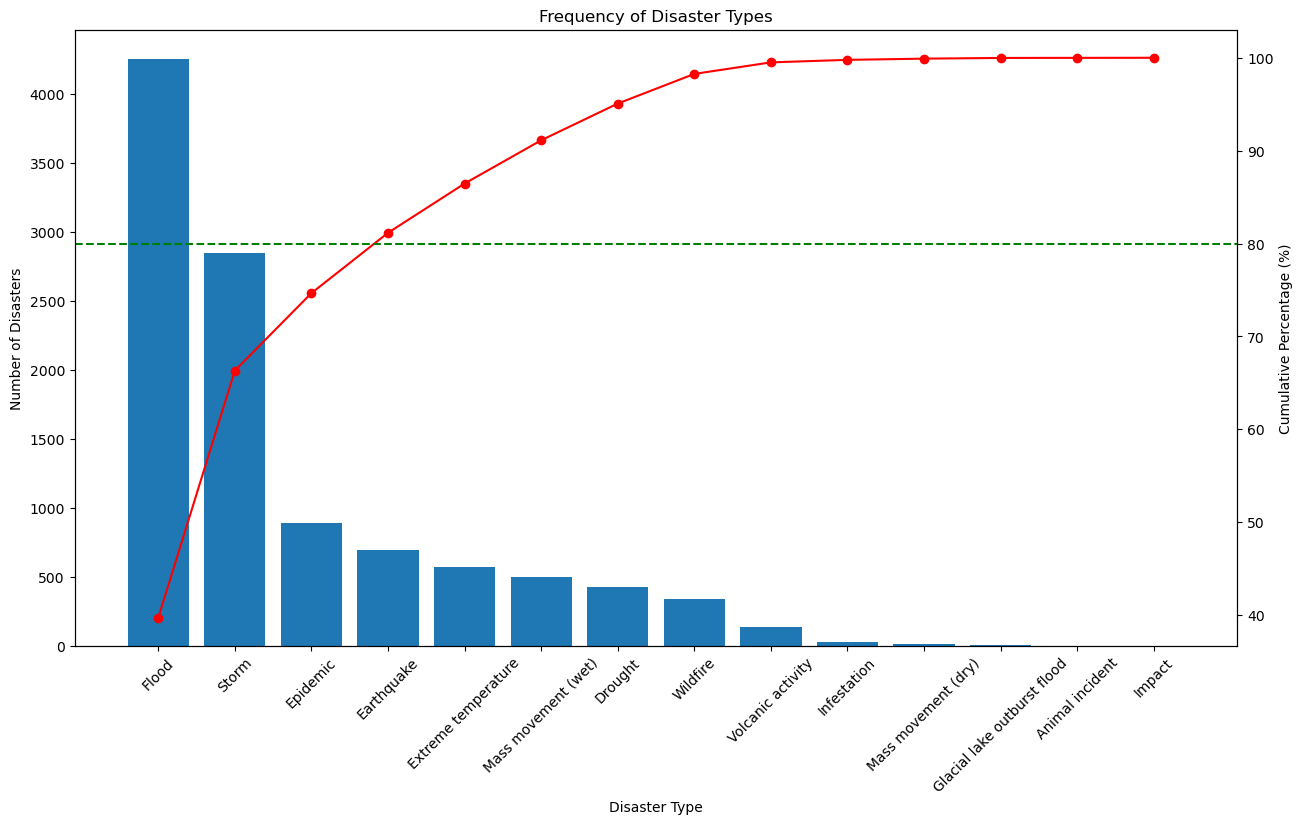

In [40]:
# printing frequency of natural disaster types
disaster_count = df_EMDAT["Disaster Type"].value_counts()
cumulative_percentage = disaster_count.cumsum() / disaster_count.sum() * 100 

# bar chart figure
fig, ax1 = plt.subplots(figsize=(15,8))
ax1.bar(disaster_count.index, disaster_count.values)
ax1.set_xlabel("Disaster Type")
ax1.set_ylabel("Number of Disasters")
plt.xticks(rotation = 45)

# cumulative percentage chart
ax2 = ax1.twinx()
ax2.plot(disaster_count.index, cumulative_percentage, color="red", marker="o")
ax2.set_ylabel("Cumulative Percentage (%)")
ax2.axhline(80, color="green", linestyle="--")

plt.title("Frequency of Disaster Types")
plt.show()


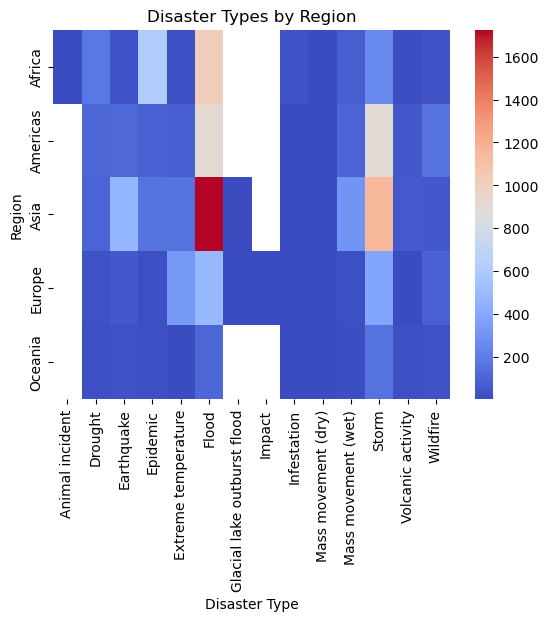

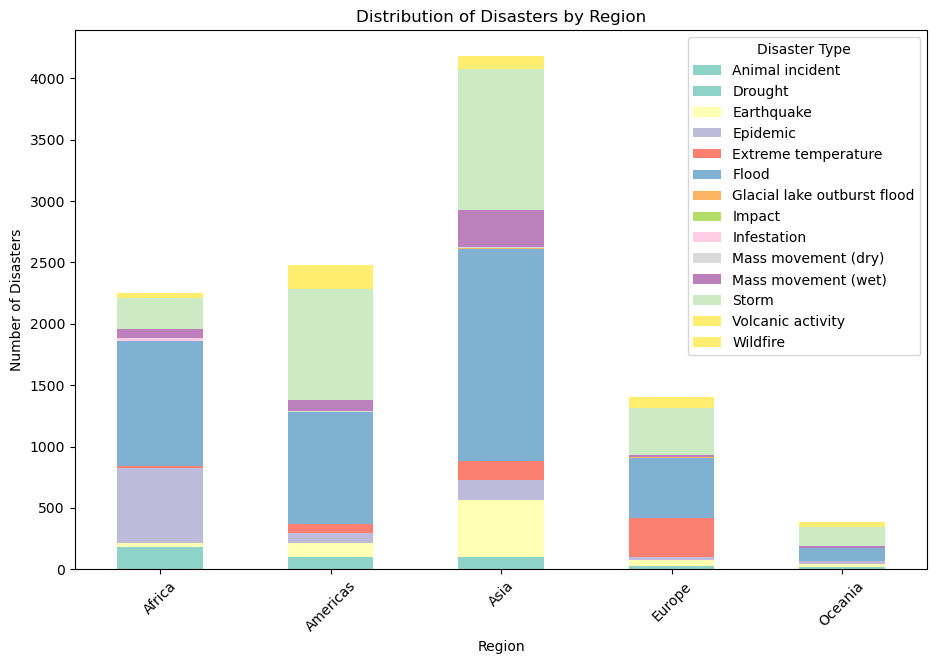

In [41]:
# printing disasters by region and type
# heatmap plot
disaster_region_type = df_EMDAT.groupby(["Region", "Disaster Type"]).size().unstack()

sns.heatmap(disaster_region_type, cmap="coolwarm")

plt.title("Disaster Types by Region")
plt.xlabel("Disaster Type")
plt.ylabel("Region")
plt.show()

# bar graph plot 
disaster_region_type.plot(kind="bar", stacked=True, figsize=(11,7), colormap="Set3")

plt.xlabel("Region")
plt.ylabel("Number of Disasters")
plt.title("Distribution of Disasters by Region")
plt.xticks(rotation = 45)
plt.show()

In [42]:
# map visualisation for common natural disasters
df_map = df_combined.dropna(subset=['Latitude', 'Longitude'])

fig = plt.figure(figsize=(16,10))
fig = px.scatter_geo(
    df_map,
    lat='latitude', 
    lon='longitude', 
    color="Disaster Type", 
    hover_name='Country', 
    title='Natural Disasters Around the World'
)

fig.show()

<Figure size 1600x1000 with 0 Axes>

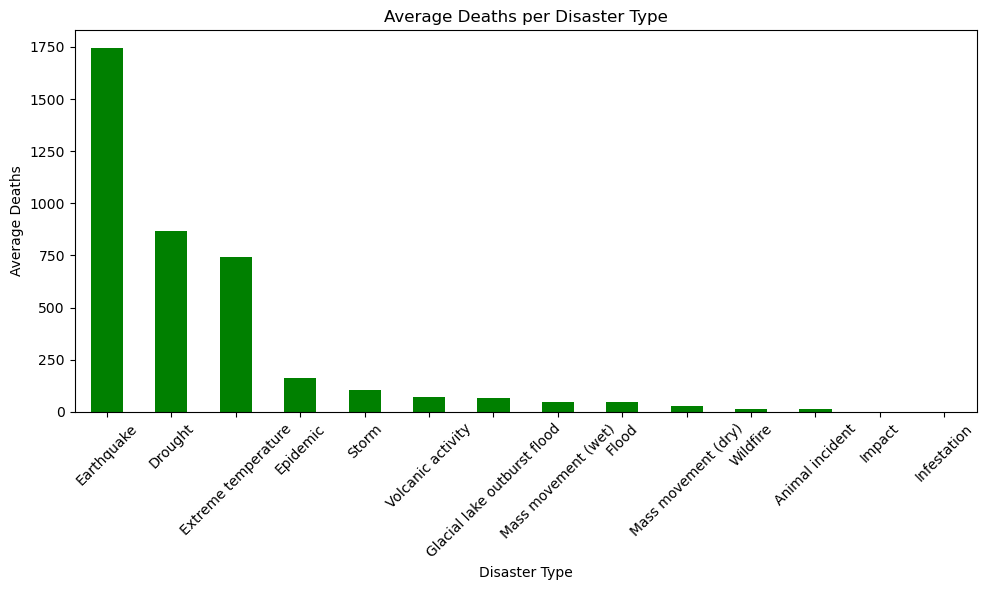

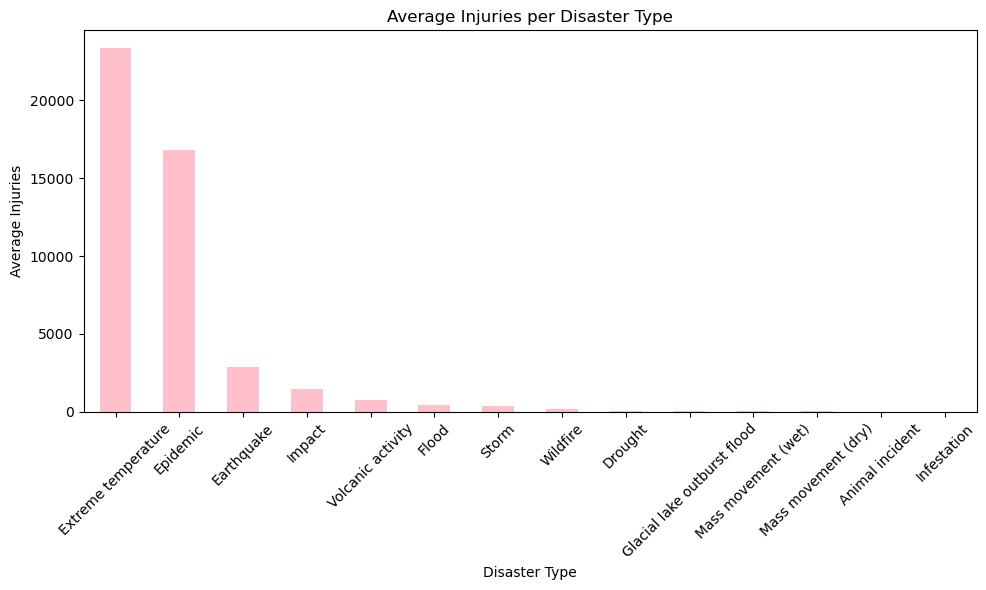

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Animal incident'),
  Text(1, 0, 'Drought'),
  Text(2, 0, 'Earthquake'),
  Text(3, 0, 'Epidemic'),
  Text(4, 0, 'Extreme temperature'),
  Text(5, 0, 'Flood'),
  Text(6, 0, 'Glacial lake outburst flood'),
  Text(7, 0, 'Impact'),
  Text(8, 0, 'Infestation'),
  Text(9, 0, 'Mass movement (dry)'),
  Text(10, 0, 'Mass movement (wet)'),
  Text(11, 0, 'Storm'),
  Text(12, 0, 'Volcanic activity'),
  Text(13, 0, 'Wildfire')])

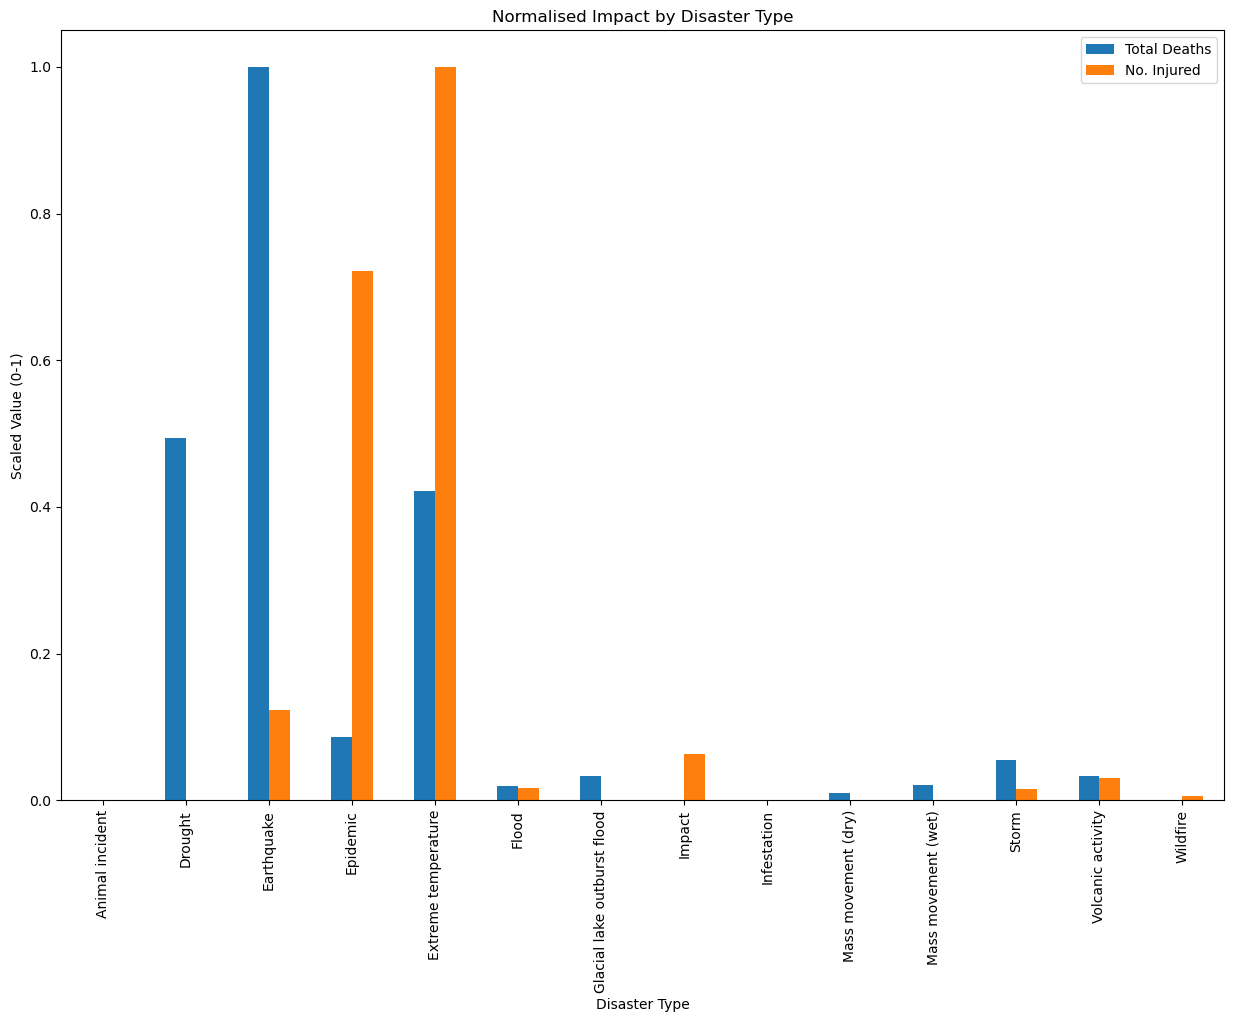

In [43]:
# comparing impact and the type of disaster, looking at injuries and death specifically
# ----- DEATHS ------ 
df = df_EMDAT.copy()
df["Total Deaths"] = pd.to_numeric(df["Total Deaths"], errors="coerce")
disaster_deaths = df.groupby("Disaster Type")["Total Deaths"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
disaster_deaths.plot(kind="bar", color="green")

plt.title("Average Deaths per Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Average Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----- INJURIES -----
df_injuries = df_EMDAT.copy()
df_injuries["No. Injured"] = pd.to_numeric(df_injuries["No. Injured"], errors="coerce")
disaster_injuries = df_injuries.groupby("Disaster Type")["No. Injured"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
disaster_injuries.plot(kind="bar", color="pink")

plt.title("Average Injuries per Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Average Injuries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----- NORMALISATION -----
# normalising values so can be compared 
scaler = MinMaxScaler() 
combined = df.groupby("Disaster Type")[["Total Deaths", "No. Injured"]].mean()

scaled = pd.DataFrame(
    scaler.fit_transform(combined),
    columns=combined.columns,
    index=combined.index
)

scaled.plot(kind="bar", figsize=(15,10))
plt.title("Normalised Impact by Disaster Type")
plt.ylabel("Scaled Value (0-1)")
plt.xticks(rotation=90)

             Disaster Type                     Country  Start Year  \
399             Earthquake                       Haiti        2010   
477             Earthquake                   Indonesia        2004   
10047                Storm                     Myanmar        2008   
6017            Earthquake                       China        2008   
7919            Earthquake                    Pakistan        2005   
8862   Extreme temperature          Russian Federation        2010   
7447            Earthquake                     Türkiye        2023   
430             Earthquake                   Sri Lanka        2004   
830             Earthquake  Iran (Islamic Republic of)        2003   
5601   Extreme temperature                       Italy        2003   

       Total Deaths  
399        222570.0  
477        165708.0  
10047      138366.0  
6017        87476.0  
7919        73338.0  
8862        55736.0  
7447        53000.0  
430         35399.0  
830         26796.0  
5601     

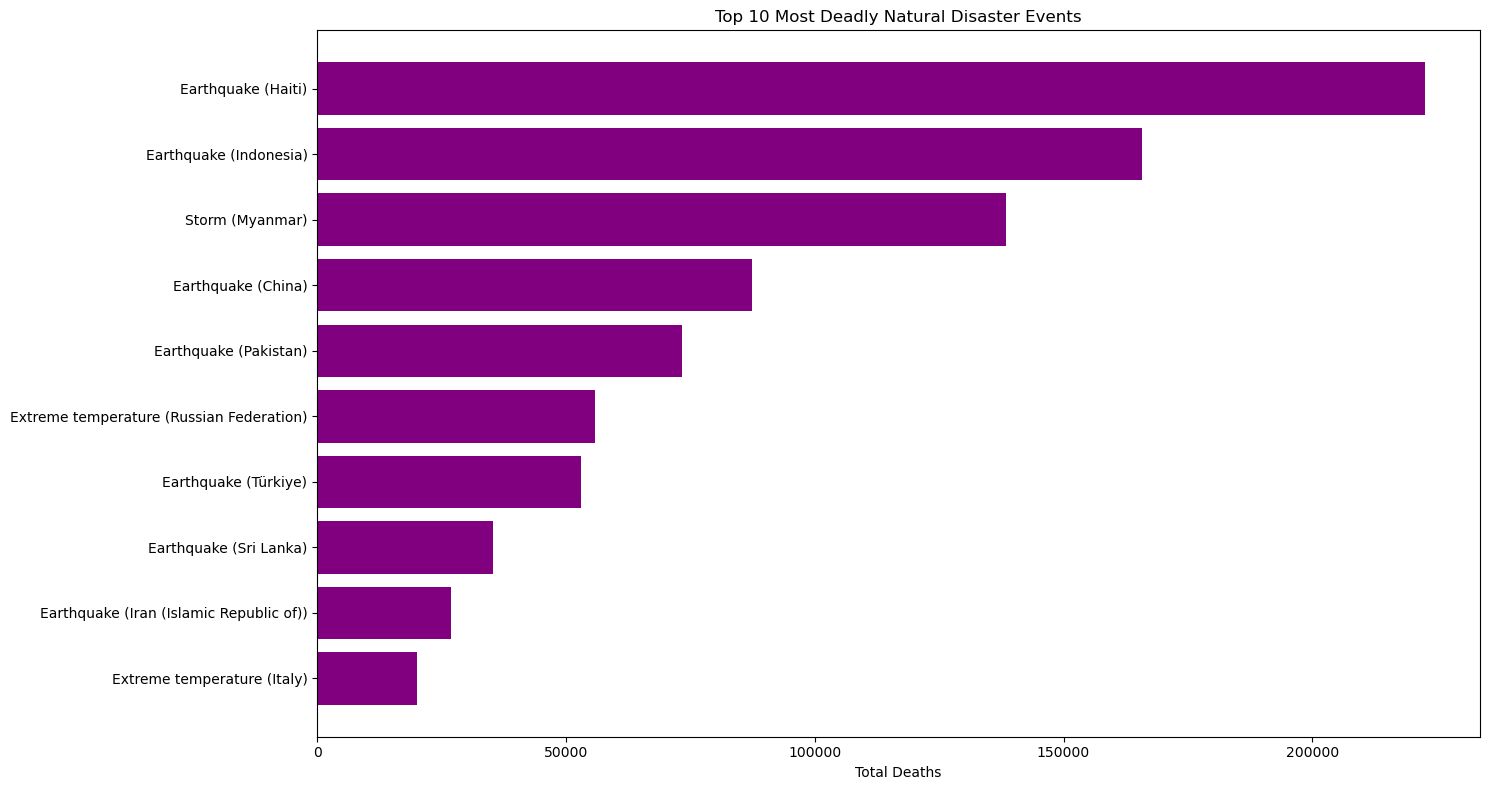

0.7
0.7561794376182442
  Disaster Type                   Country  Start Year  Total Damage ('000 US$)
0    Earthquake                     Japan        2011              210000000.0
1         Storm  United States of America        2005              125000000.0
2         Storm  United States of America        2022              100000000.0
3         Storm  United States of America        2017               95000000.0
4    Earthquake                     China        2008               85000000.0
5         Storm               Puerto Rico        2017               68000000.0
6         Storm  United States of America        2021               65000000.0
7         Storm  United States of America        2017               57000000.0
8         Storm  United States of America        2024               56000000.0
9      Wildfire  United States of America        2025               53000000.0
10


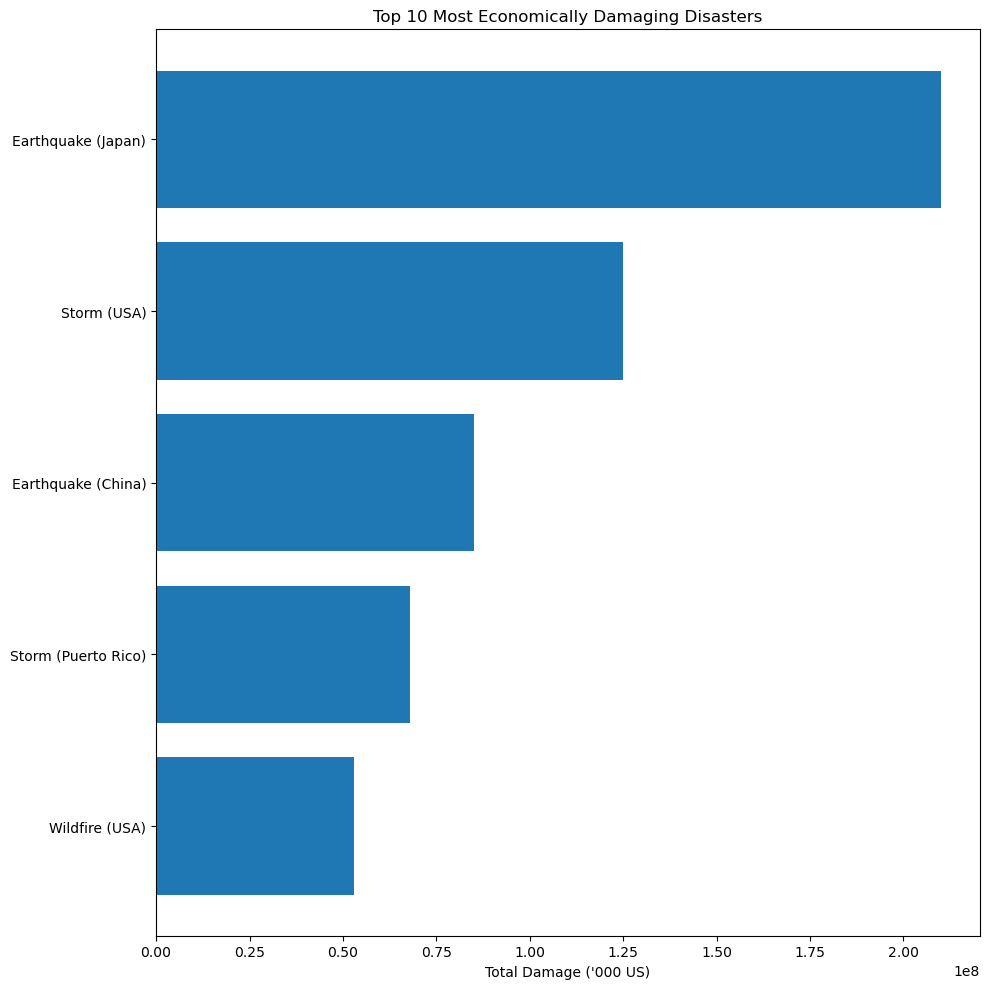

In [ ]:
# looking at extreme events in the dataset 
# ----- top 10 most deadly disaster types -----
df = df_EMDAT.copy()
df["Total Deaths"] = pd.to_numeric(df["Total Deaths"], errors="coerce")

top_deaths = df.sort_values(by="Total Deaths", ascending=False).head(10)
print(top_deaths[["Disaster Type", "Country", "Start Year", "Total Deaths"]])

plt.figure(figsize=(15, 8))
plt.barh(
    top_deaths["Disaster Type"] + " (" + top_deaths["Country"] + ")",
    top_deaths["Total Deaths"],
    color='purple'
)

plt.gca().invert_yaxis()
plt.title("Top 10 Most Deadly Natural Disaster Events")
plt.xlabel("Total Deaths")
plt.tight_layout()
plt.show()

# percentage/shares of the top 10 being earthquakes
earthquake_count = (top_deaths["Disaster Type"] == "Earthquake").sum()
proportion = earthquake_count / len(top_deaths)
print(proportion)

total_top_deaths = top_deaths["Total Deaths"].sum()
earthquake_deaths = top_deaths[top_deaths["Disaster Type"] == "Earthquake"]["Total Deaths"].sum()
share = earthquake_deaths / total_top_deaths
print(share)

# ----- top 10 disasters with most economic impact -----
# SCRAPPED - NOT ENOUGH EVENTS
df["Total Damage ('000 US$)"] = pd.to_numeric(df["Total Damage ('000 US$)"], errors="coerce")

top_economic = df.sort_values(by="Total Damage ('000 US$)", ascending=False).head(10)
top_economic = top_economic.reset_index(drop=True)

print(top_economic[["Disaster Type", "Country", "Start Year", "Total Damage ('000 US$)"]])
print(len(top_economic))

labels = top_economic["Disaster Type"] + " (" + top_economic["Country"] + ")"
labels = labels.str.replace("United States of America", "USA")

plt.figure(figsize=(10, 10))
plt.barh(
    labels,
    top_economic["Total Damage ('000 US$)"]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Most Economically Damaging Disasters")
plt.xlabel("Total Damage ('000 US)")
plt.tight_layout()
plt.show()

## Links to Atmospheric Dataset

This section looks into the potential links between data in the EMDAT dataset and our existing data about atmospheric variables. 

In [45]:
# defining columns and locations for MET office data
columns = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "Temperature",
    "Percipitation",
    "U-wind",
    "V-wind"
]

locations = {
    "-33.5N_151E": "Australia",
    "-33.9N_18.5E": "South Africa",
    "17.36N_78.5E": "India",
    "18N_283.2E": "Jamaica",
    "40.75N_286.01E": "USA",
    "41.9N_12.46E": "Italy",
    "43.28N_5.39E": "France",
    "43.64N_280.63E": "Canada (Toronto)", 
    "51.03N_245.94E": "Canada (Calgary)",
    "51.5N_359.9E": "United Kingdom",
    "58.76N_265.83E": "Canada (Churchill)",
    "59.92N_10.75E": "Norway"
}

# loading MET office dataset 
files = glob.glob("../visualisation/dataset/*.csv")
dfs = []

for file in files:
    df = pd.read_csv(file, header=None, names=columns)
    df["location"] = file.split("/")[-1].replace(".csv", "")
    dfs.append(df)

df_METOFFICE = pd.concat(dfs, ignore_index=True)
df_METOFFICE["datetime"] = pd.to_datetime(df_METOFFICE[["Year", "Month", "Day", "Hour"]])

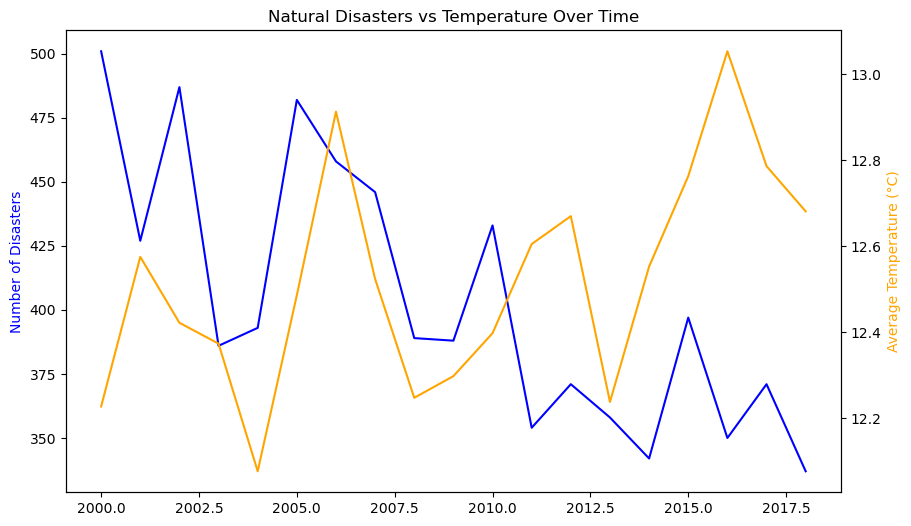

Index(['Year', 'Month', 'Day', 'Hour', 'Temperature', 'Percipitation',
       'U-wind', 'V-wind', 'location', 'datetime'],
      dtype='object')
['43.28N_5.39E' '59.92N_10.75E' '17.36N_78.5E' '-33.9N_18.5E'
 '-33.5N_151E' '51.03N_245.94E' '43.64N_280.63E' '51.5N_359.9E'
 '58.76N_265.83E' '40.75N_286.01E' '18N_283.2E' '41.9N_12.46E']


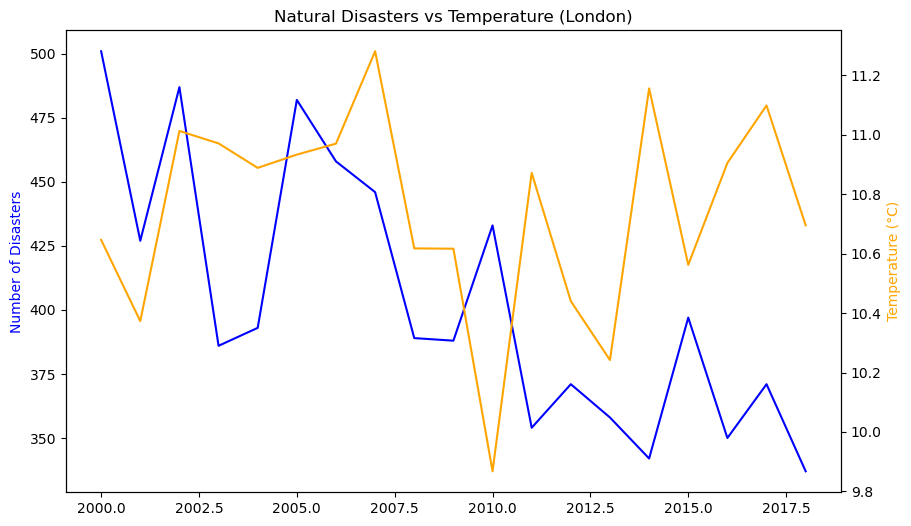

In [46]:
# time series plot linking temperature with occurrence of natural disasters
yearly_temperature = df_METOFFICE.groupby("Year")["Temperature"].mean()
yearly_disasters = df_EMDAT.groupby("Start Year").size()

common_years = yearly_temperature.index.intersection(yearly_disasters.index)
yearly_temperature = yearly_temperature.loc[common_years]
yearly_disasters = yearly_disasters.loc[common_years]

yearly_temperature_c = yearly_temperature - 273.15

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(common_years, yearly_disasters, color='blue')
ax1.set_ylabel("Number of Disasters", color='blue')

ax2 = ax1.twinx()
ax2.plot(common_years, yearly_temperature_c, color='orange')
ax2.set_ylabel("Average Temperature (°C)", color='orange')

plt.title("Natural Disasters vs Temperature Over Time")
plt.show()


# trying to plot for one specific location
print(df_METOFFICE.columns)
print(df_METOFFICE["location"].unique())

yearly_disasters = df_EMDAT.groupby("Start Year").size()

uk_temp = df_METOFFICE[df_METOFFICE["location"] == "51.5N_359.9E"]
yearly_temperature_uk = uk_temp.groupby("Year")["Temperature"].mean()

common_years_uk = yearly_temperature_uk.index.intersection(yearly_disasters.index)

temp_uk = yearly_temperature_uk.loc[common_years_uk]
disasters_uk = yearly_disasters.loc[common_years_uk]

temp_uk_c = temp_uk - 273.15

fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(common_years_uk, disasters_uk, color='blue')
ax1.set_ylabel("Number of Disasters", color="blue")

ax2 = ax1.twinx()
ax2.plot(common_years_uk, temp_uk_c, color='orange')
ax2.set_ylabel("Temperature (°C)", color='orange')

plt.title("Natural Disasters vs Temperature (London)")
plt.show()


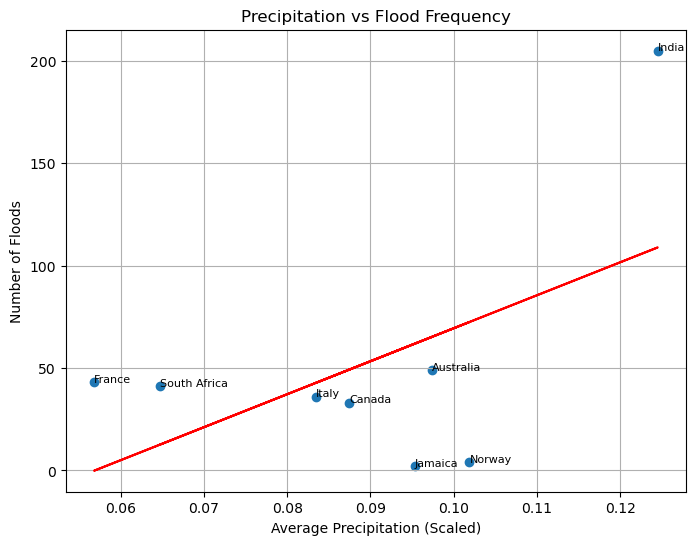

In [47]:
# link between country level of precipitation from our dataset and floods
df_METOFFICE["Country"] = df_METOFFICE["location"].map(locations)
df_METOFFICE["Country"] = df_METOFFICE["Country"].str.replace(r"\(.*\)", "", regex=True).str.strip()

precipitation_by_country = df_METOFFICE.groupby("Country")["Percipitation"].mean()

floods = df_EMDAT[df_EMDAT["Disaster Type"] == "Flood"]
floods_by_country = floods.groupby("Country").size()

floods_combined = precipitation_by_country.to_frame("Percipitation").merge(
    floods_by_country.to_frame("Floods"),
    left_index=True,
    right_index=True
)

# rescaling precipitation
floods_combined["Percipitation"] = floods_combined["Percipitation"] * 1000

plt.figure(figsize=(8,6))
plt.scatter(floods_combined["Percipitation"], floods_combined["Floods"])

# adding labels
for country in floods_combined.index:
    plt.text(
        floods_combined.loc[country, "Percipitation"],
        floods_combined.loc[country, "Floods"],
        country,
        fontsize=8
    )

# trend line 
x = floods_combined["Percipitation"]
y = floods_combined["Floods"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")

plt.xlabel("Average Precipitation (Scaled)")
plt.ylabel("Number of Floods")
plt.title("Precipitation vs Flood Frequency")
plt.grid(True)
plt.show()

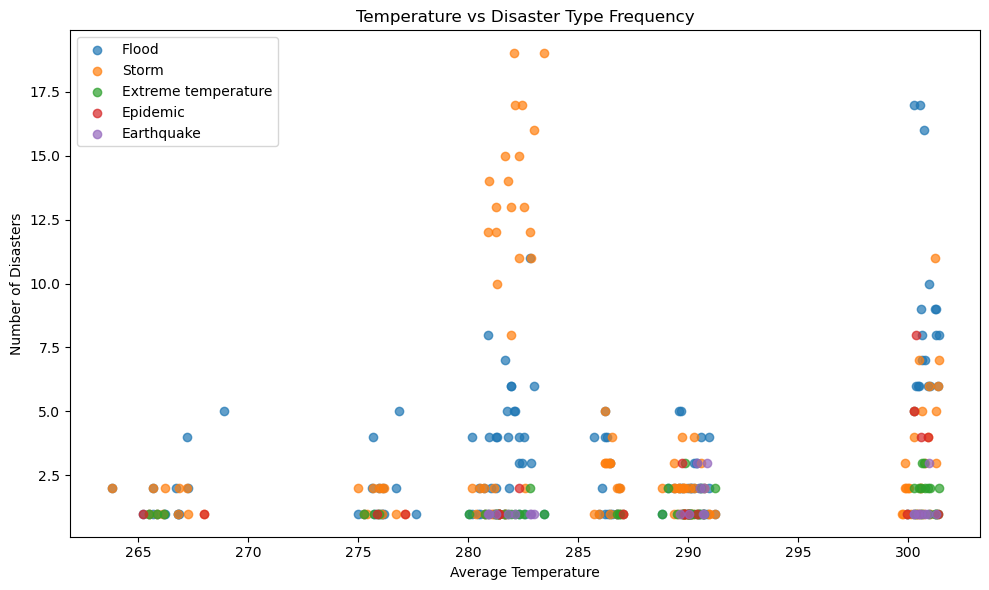

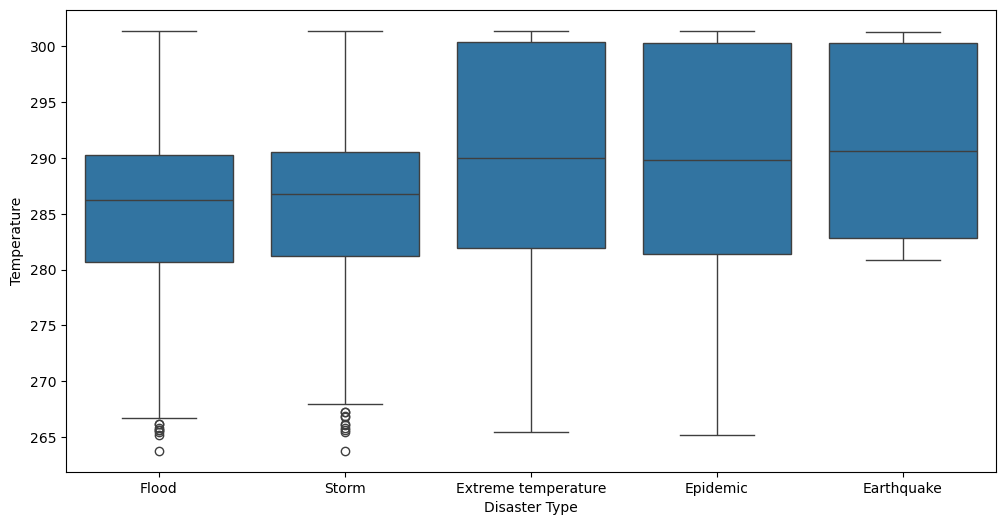

In [57]:
# temperature vs disaster type breakdown
# making climate yearly variables 
df_METOFFICE["Temperature"] = pd.to_numeric(df_METOFFICE["Temperature"], errors="coerce")
df_METOFFICE["Percipitation"] = pd.to_numeric(df_METOFFICE["Percipitation"], errors="coerce")
df_METOFFICE["Year"] = pd.to_numeric(df_METOFFICE["Year"], errors="coerce")

climate_yearly = df_METOFFICE.groupby(["location", "Year"]).agg({
    "Temperature": "mean",
    "Percipitation": "mean"
}).reset_index()

locations = {
    "-33.5N_151E": "Australia",
    "-33.9N_18.5E": "South Africa",
    "17.36N_78.5E": "India",
    "18N_283.2E": "Jamaica",
    "40.75N_286.01E": "United States of America",
    "41.9N_12.46E": "Italy",
    "43.28N_5.39E": "France",
    "43.64N_280.63E": "Canada",
    "51.03N_245.94E": "Canada",
    "51.5N_359.9E": "United Kingdom",
    "58.76N_265.83E": "Canada",
    "59.92N_10.75E": "Norway"
}

climate_yearly["Country_Link"] = climate_yearly["location"].map(locations)
climate_yearly = climate_yearly.dropna(subset=["Country_Link"])

df_dis = df_EMDAT.copy()
df_dis["Start Year"] = pd.to_numeric(df_dis["Start Year"], errors="coerce")

dis_type_year = df_dis.groupby(
    ["Country", "Start Year", "Disaster Type"]
).size().reset_index(name="Count")

merged_type = pd.merge(
    climate_yearly,
    dis_type_year,
    left_on=["Country_Link", "Year"],
    right_on=["Country", "Start Year"],
    how="inner"
)

top_types = df_dis["Disaster Type"].value_counts().head(5).index
merged_type = merged_type[merged_type["Disaster Type"].isin(top_types)]

plt.figure(figsize=(10,6))

for d_type in merged_type["Disaster Type"].unique():
    subset = merged_type[merged_type["Disaster Type"] == d_type]
    
    plt.scatter(
        subset["Temperature"],
        subset["Count"],
        label=d_type,
        alpha=0.7
    )

plt.title("Temperature vs Disaster Type Frequency")
plt.xlabel("Average Temperature")
plt.ylabel("Number of Disasters")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_type, x="Disaster Type", y="Temperature")
plt.show()